⚠️ Execution note

This notebook shows the original exploratory work. Paths no longer match because the project was later refactored into Python scripts. The logic is correct, but the notebook will not run without updating the paths. It is kept only for documentation/versioning purposes.

Load and merge datasets

Loading the `orders.csv` and `order_products__prior.csv` files from the Instacart dataset.  
The goal is to merge them so that each order can be linked to the corresponding user.

In [1]:
import pandas as pd
import numpy as np

# Load datasets from data folder
orders = pd.read_csv("../data/orders.csv")
order_products_prior = pd.read_csv("../data/order_products__prior.csv")

# Keep only prior orders (exclude train/test)
orders_prior = orders[orders["eval_set"] == "prior"]

# Merge to attach user_id to each order-product
merged = pd.merge(order_products_prior, orders_prior, on="order_id", how="inner")

print("Merged shape:", merged.shape)
merged.head()


Merged shape: (32434489, 10)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,prior,3,5,9,8.0
1,2,28985,2,1,202279,prior,3,5,9,8.0
2,2,9327,3,0,202279,prior,3,5,9,8.0
3,2,45918,4,1,202279,prior,3,5,9,8.0
4,2,30035,5,0,202279,prior,3,5,9,8.0


Keep users with at least 3 orders

To measure periodicity reliably, we only consider users with at least 3 completed orders.  
Users with fewer purchases do not provide enough data to estimate frequency.

In [2]:
# Count number of unique orders per user
order_counts = merged.groupby("user_id")["order_number"].nunique().reset_index()
order_counts.columns = ["user_id", "num_orders"]

# Keep only users with >= 3 orders
valid_users = order_counts[order_counts["num_orders"] >= 3]["user_id"]
merged = merged[merged["user_id"].isin(valid_users)]

print("Number of valid users:", merged['user_id'].nunique())

Number of valid users: 206209


Compute periodicity metrics per user

For each user, we calculate:
- the **mean** number of days between orders,
- the **standard deviation** of these intervals,
- and the **coefficient of variation (CV)** defined as `std / mean`.

In [3]:
# Aggregate mean, std, and count per user
periodicity = (
    merged.groupby("user_id")["days_since_prior_order"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Coefficient of Variation (CV = std / mean)
periodicity["cv"] = periodicity["std"] / periodicity["mean"]
periodicity.head()

,user_id,mean,std,count,cv
0,1,20.259259,9.304463,54,0.459270
1,2,15.967033,9.119769,182,0.571162
2,3,11.487179,4.869048,78,0.423868
3,4,15.357143,8.580901,14,0.558756
4,5,14.500000,4.263801,26,0.294055


Categorize users by purchase periodicity

We classify users according to their CV value:
- **CV < 0.5:** Stable periodicity  
- **0.5 ≤ CV ≤ 1:** Moderate periodicity  
- **CV > 1:** Irregular / random purchase pattern

In [4]:
def categorize(cv):
    if cv < 0.5:
        return "Stable Periodicity"
    elif cv <= 1:
        return "Moderate Periodicity"
    else:
        return "Irregular"

periodicity["periodicity_category"] = periodicity["cv"].apply(categorize)

# Display overall distribution
summary = periodicity["periodicity_category"].value_counts(normalize=True) * 100
print("User distribution by periodicity category (%):")
print(summary.round(2))

User distribution by periodicity category (%):
periodicity_category
Moderate Periodicity    48.54
Stable Periodicity      48.44
Irregular                3.02
Name: proportion, dtype: float64


Save results for further analysis

We export the computed periodicity metrics to a CSV file, so they can be reused for visualization or user clustering.

In [5]:
periodicity.to_csv("../data/user_periodicity.csv", index=False)
print("File saved successfully to '../data/user_periodicity.csv'")

File saved successfully to '../data/user_periodicity.csv'


Visualization: Coefficient of Variation (CV) Distribution

This histogram shows how CV values are distributed among users.  
The green and red dashed lines mark the thresholds for stable (0.5) and irregular (1.0) patterns.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

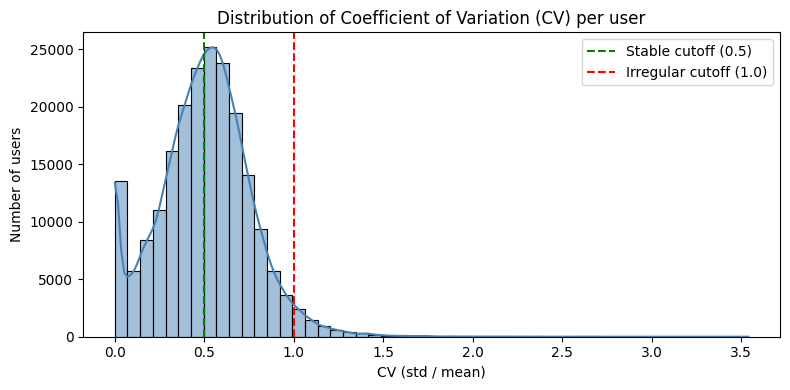

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(periodicity["cv"], bins=50, kde=True, color="steelblue")
plt.axvline(0.5, color='green', linestyle='--', label='Stable cutoff (0.5)')
plt.axvline(1.0, color='red', linestyle='--', label='Irregular cutoff (1.0)')
plt.title("Distribution of Coefficient of Variation (CV) per user")
plt.xlabel("CV (std / mean)")
plt.ylabel("Number of users")
plt.legend()
plt.tight_layout()
plt.show()

Boxplot of CV by periodicity category

The boxplot confirms that the defined categories (Stable, Moderate, Irregular)  
have distinct ranges of CV values, validating the chosen thresholds.

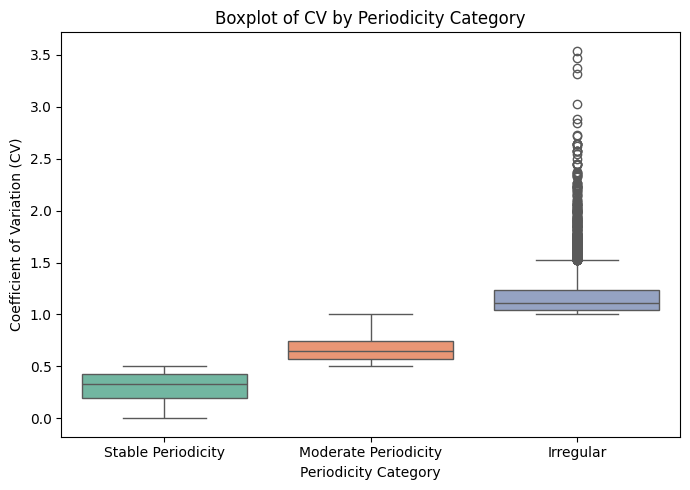

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="periodicity_category",
    y="cv",
    hue="periodicity_category",     # required for palette
    data=periodicity,
    order=["Stable Periodicity", "Moderate Periodicity", "Irregular"],
    palette="Set2",
    legend=False                    # prevents duplicate legend
)
plt.title("Boxplot of CV by Periodicity Category")
plt.xlabel("Periodicity Category")
plt.ylabel("Coefficient of Variation (CV)")
plt.tight_layout()
plt.show()


Visualization: Mean days between orders

This histogram displays the average number of days between purchases.  
Peaks around 5–10 and 30 days indicate weekly and monthly shopping cycles.

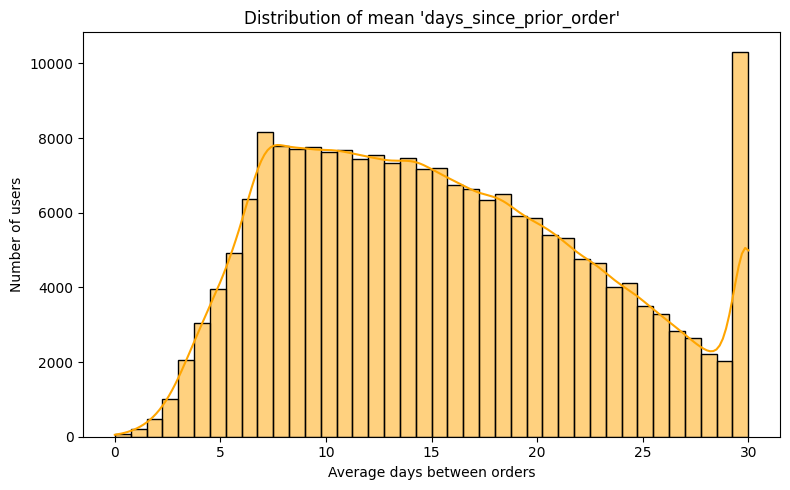

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(periodicity["mean"], bins=40, kde=True, color="orange")
plt.title("Distribution of mean 'days_since_prior_order'")
plt.xlabel("Average days between orders")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

Summary of user periodicity categories

Finally, we print the percentage of users classified as stable, moderate, or irregular.  
These proportions demonstrate that most users show stable or moderately stable purchasing behavior.

In [10]:
category_counts = periodicity["periodicity_category"].value_counts(normalize=True) * 100
print("User Periodicity Distribution (%):")
print(category_counts.round(2))

User Periodicity Distribution (%):
periodicity_category
Moderate Periodicity    48.54
Stable Periodicity      48.44
Irregular                3.02
Name: proportion, dtype: float64
